<a href="https://colab.research.google.com/github/LuxTenebriis/SMC_SED/blob/main/Lux_SMC_SED_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ★ SMC Stellar Energy Distribution Plots ★

☆ last updated: 10/05/2026
<br>
<br>
LAYOUT☆☆☆<br>
Setup ⟶ import all packagaes, set path directories and define photometry columns <br>
Functions ⟶  implement the standarised functions for data processing (aka "cleaning" the columns) and plotting the diagrams
<br><br>
YSG ⟶ calls the functions for analysis of YSG candidates <br>
<br>
☆ U-M GPT was used to assist with Python syntax, code organization, debugging, and editing.

---



## ★ SETUP

In [ ]:
import pandas as pd
import numpy as np
import csv
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D

In [ ]:
#connect to google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#set up paths
main_path= Path("/content/drive/MyDrive/★ Research/Unresolved Binaries")
data_path = main_path / "Data/SMC_Data/"
YSG_path = data_path / "smc_ysg.csv"
output_path= main_path / "Outputs/SED"

In [ ]:
# define column names
magnitude_cols = [
    "umagSkyM",
    "vmagSkyM",
    "imagSkyM"
]

error_cols = [
    "e_umagSkyM",
    "e_vmagSkyM",
    "e_imagSkyM"
]

# Approximate SkyMapper filter central wavelengths in nanometers
wavelengths = np.array([
    349.0,  # SkyMapper u
    384.0,  # SkyMapper v
    779.0   # SkyMapper i
])

In [ ]:
# read file
table_raw = pd.read_csv(YSG_path)
table = table_raw.copy()

In [ ]:
#EDITS ★ only keep: type of star, filters, corresponding marg error cols
# aka remove the unamed column, and the position (x,y) columns
table = table.drop(columns=["ID"], errors="ignore")

#convert to numeric values for later plotting
#converts nonnumeric entries into "n/a"
for col in magnitude_cols + error_cols:
  table[col] = pd.to_numeric(table[col], errors='coerce')

#round numerical values to 2 decimal points
table[magnitude_cols]= table[magnitude_cols].round(2)
table[error_cols]= table[error_cols].round(2)

print("Raw Table:")
display(table_raw)
print("Clean Table — All Available Data:")
display(table)

Raw Table:


,ID,umagSkyM,e_umagSkyM,vmagSkyM,e_vmagSkyM,imagSkyM,e_imagSkyM
0,2249,16.904,0.085,15.990,0.037,14.562,0.046
1,2278,15.898,0.023,15.623,0.019,14.270,0.003
2,2361,15.518,0.023,14.594,0.007,13.511,0.005
3,2726,15.807,0.020,14.816,0.023,13.648,0.007
4,3584,16.415,0.071,15.703,0.127,14.054,0.025
5,3604,16.108,0.019,15.069,0.003,13.982,0.008
6,3839,16.429,0.164,15.849,0.161,14.441,0.062
7,4053,16.180,0.030,15.251,0.017,14.138,0.002
8,4861,16.756,0.267,16.247,0.179,14.256,0.038
9,5261,15.947,0.023,15.097,0.007,13.734,0.005


Clean Table — All Available Data:


,umagSkyM,e_umagSkyM,vmagSkyM,e_vmagSkyM,imagSkyM,e_imagSkyM
0,16.90,0.08,15.99,0.04,14.56,0.05
1,15.90,0.02,15.62,0.02,14.27,0.00
2,15.52,0.02,14.59,0.01,13.51,0.00
3,15.81,0.02,14.82,0.02,13.65,0.01
4,16.42,0.07,15.70,0.13,14.05,0.02
5,16.11,0.02,15.07,0.00,13.98,0.01
6,16.43,0.16,15.85,0.16,14.44,0.06
7,16.18,0.03,15.25,0.02,14.14,0.00
8,16.76,0.27,16.25,0.18,14.26,0.04
9,15.95,0.02,15.10,0.01,13.73,0.00


NameError: name 'filename' is not defined

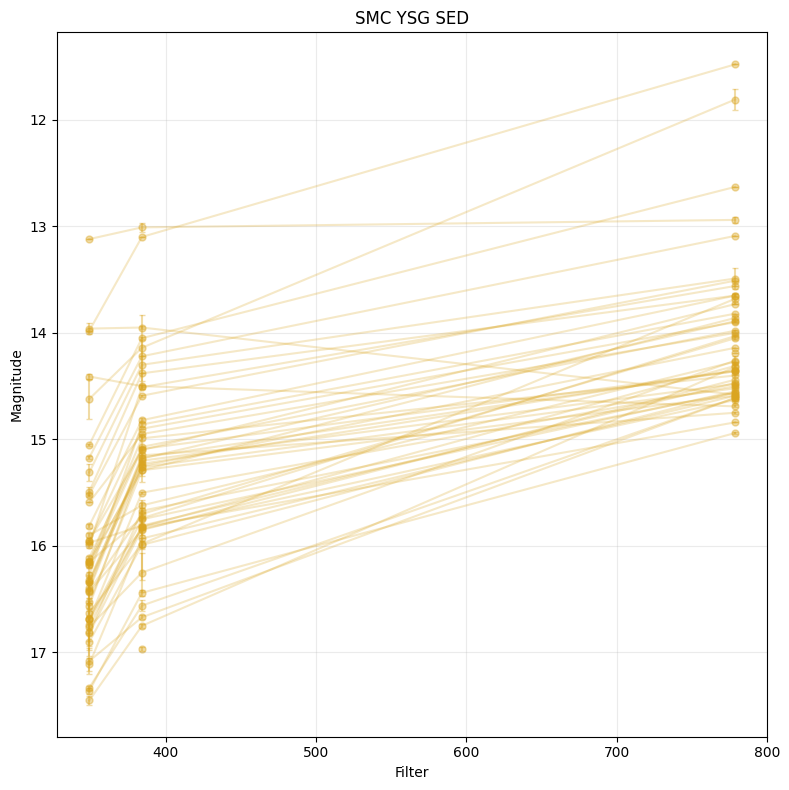

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))

for _, star in table.iterrows():

    magnitudes = star[magnitude_cols].to_numpy(float)
    errors = star[error_cols].to_numpy(float)

    valid = np.isfinite(magnitudes)
    valid_errors = valid & np.isfinite(errors)

    # Plot all available measurements
    ax.scatter(
        wavelengths[valid],
        magnitudes[valid],
        s=25,
        color="goldenrod",
        alpha=0.4
    )

    # Add error bars where errors are available
    ax.errorbar(
        wavelengths[valid_errors],
        magnitudes[valid_errors],
        yerr=errors[valid_errors],
        linestyle="none",
        capsize=2,
        color="goldenrod",
        alpha=0.4
    )

    # Connect the points if all three filters are available
    if valid.all():
        ax.plot(
            wavelengths,
            magnitudes,
            color="goldenrod",
            alpha=0.25
        )

ax.invert_yaxis()

ax.set_xlabel("Filter")
ax.set_ylabel("Magnitude")
ax.set_title("SMC YSG SED")

ax.grid(alpha=0.25)

plt.tight_layout()

figure_path = Path(output_path) / filename
plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()



---



## ★ FUNCTIONS